In [ ]:
!pip install huggingface_hub -q
from huggingface_hub import HfApi
api = HfApi()
HF_TOKEN = "..."  # add your hf_token here
REPO_ID = "Awan8754/celeba-dcgan"


In [9]:
# importing libs

import os
import torch
from torchvision import transforms, datasets
from torch.utils.data import DataLoader, Dataset
import matplotlib.pyplot as plt 

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [5]:
"""
Resize  : convert the images from whatever dim to 64x64
ToTensor : convert the PIL to a tensor and convert the 255 to 0-1
Normalize : convert the 0-1 values to -1 ,1 
"""
transform = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

In [6]:
#importing data from celebA , a subset of 30k images

import os
import random

base_path = "/kaggle/input/datasets/jessicali9530/celeba-dataset/img_align_celeba/img_align_celeba"

all_images = os.listdir(base_path)
random.seed(42)
subset_images = random.sample(all_images, 30000)

print(f"Total images available: {len(all_images)}")
print(f"Subset size: {len(subset_images)}")

Total images available: 202599
Subset size: 30000


In [7]:
# make the custom dataset class

from PIL import Image

class CelebDataset(Dataset):
    def __init__(self, data_path, transform, image_list):
        self.data_path = data_path
        self.transform = transform
        self.images = image_list
    
    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = os.path.join(self.data_path,self.images[idx])
        image = Image.open(img_path).convert("RGB")
        if self.transform :
            image = self.transform(image)

        return image

In [8]:
base_path = "/kaggle/input/datasets/jessicali9530/celeba-dataset/img_align_celeba/img_align_celeba"

random.seed(42)
subset_images = random.sample(os.listdir(base_path), 30000)

dataset = CelebDataset(
    data_path=base_path,
    transform=transform,
    image_list=subset_images
)

dataloader = DataLoader(dataset, batch_size=64, shuffle=True, num_workers=2, pin_memory=True)
print(f"total images: {len(dataset)}")
print(f"total batches: {len(dataloader)}")

total images: 30000
total batches: 469


In [5]:
# write the generator

import torch.nn as nn

class Generator(nn.Module):
    def __init__(self, noise_dims =100):
        super().__init__()
        #nn.ConvTranspose2d(in_channels, out_channels, kernel_size, stride, padding, bias=False)
        self.model = nn.Sequential(
            # 100 -> 512
            nn.ConvTranspose2d(noise_dims, 512, 4, 1, 0, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(True),
            # 512 -> 256
            nn.ConvTranspose2d(512, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),
            # 256 -> 128
            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            # 128 -> 64
            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            # 64 -> 3
            nn.ConvTranspose2d(64, 3, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, x):
        return self.model(x)
        

In [6]:
# write the discriminator 

class Discriminator(nn.Module):
    def __init__(self):     #generator img is 64 dims in this case
        super().__init__()
        self.model = nn.Sequential(
            #3->64
            nn.Conv2d(3,64, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            #64->128
            nn.Conv2d(64,128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            #128->256
            nn.Conv2d(128,256,4,2,1,bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
            #256->512
            nn.Conv2d(256,512,4,2,1,bias=False),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),
            #512->1
            nn.Conv2d(512,1,4,1,0,bias=False),
            nn.Sigmoid()
        )
        
    def forward(self, x):
        return self.model(x)

In [11]:
# weights initialization 
def weights_init(m):
    classname = m.__class__.__name__
    if 'Conv' in classname:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif 'BatchNorm' in classname:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

In [12]:
# loss 
criterion = nn.BCELoss()


In [13]:
import torch.optim as optim

netG = Generator(noise_dims=100).to(device)
netD = Discriminator().to(device)

netG.apply(weights_init)
netD.apply(weights_init)

optimizer_G = optim.Adam(netG.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizer_D = optim.Adam(netD.parameters(), lr=0.0002, betas=(0.5, 0.999))

In [14]:
from torchvision.utils import save_image

fixed_noise = torch.randn(64,100,1,1).to(device)

In [15]:
from torchvision.utils import save_image
num_epochs = 30
fixed_noise = torch.randn(64,100,1,1).to(device)

for epoch in range(num_epochs):
    for i, real_images in enumerate(dataloader):
        real_images = real_images.to(device)
        batch_size = real_images.size(0)

        # now lets train the disc 
        netD.zero_grad()          #clear the old gradients
    
        # real images so disc should output 1
        real_label_true_images = torch.ones(batch_size, 1,1,1).to(device)
        disc_output_real_img = netD(real_images) 
        disc_loss_real_img = criterion(disc_output_real_img, real_label_true_images)
    
        # fake images so disc should output 0
        noise = torch.randn(batch_size,100,1,1).to(device)
        fake_images = netG(noise)
        disc_output_fake_img = netD(fake_images.detach())
        real_label_fake_images = torch.zeros(batch_size,1,1,1).to(device)
        disc_loss_fake_img = criterion(disc_output_fake_img, real_label_fake_images)
    
        total_loss_disc = disc_loss_real_img + disc_loss_fake_img
        total_loss_disc.backward()
        optimizer_D.step()
    
    
        # now lets train the gen
        netG.zero_grad()         

        gen_output = netD(fake_images)
        gen_loss = criterion(gen_output,real_label_true_images)    #disc output should be 1 if gen wants to win so we send disc prob on fake images and 1
        gen_loss.backward()
        optimizer_G.step()

        # trick 3 - print every 100 batches
        if i % 100 == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}] Batch {i}/{len(dataloader)} Loss_D: {total_loss_disc.item():.4f} Loss_G: {gen_loss.item():.4f}")


    if (epoch+1) % 5 == 0:
        with torch.no_grad():
            fake = netG(fixed_noise)
            save_image(fake, f"/kaggle/working/epoch_{epoch+1}.png", normalize=True, nrow=8)
            print(f"images saved at epoch {epoch+1}")

    if (epoch+1) % 10 == 0:
        torch.save(netG.state_dict(), "/kaggle/working/netG_latest.pth")
        torch.save(netD.state_dict(), "/kaggle/working/netD_latest.pth")
        api.upload_file(path_or_fileobj="/kaggle/working/netG_latest.pth", path_in_repo="netG_latest.pth", repo_id=REPO_ID, token=HF_TOKEN)
        api.upload_file(path_or_fileobj="/kaggle/working/netD_latest.pth", path_in_repo="netD_latest.pth", repo_id=REPO_ID, token=HF_TOKEN)
        print(f"checkpoint saved to HF at epoch {epoch+1}")



Epoch [1/30] Batch 0/469 Loss_D: 0.4788 Loss_G: 5.3113
Epoch [1/30] Batch 100/469 Loss_D: 0.4136 Loss_G: 3.6374
Epoch [1/30] Batch 200/469 Loss_D: 0.6912 Loss_G: 2.6556
Epoch [1/30] Batch 300/469 Loss_D: 0.3035 Loss_G: 3.3502
Epoch [1/30] Batch 400/469 Loss_D: 0.6105 Loss_G: 4.7205
Epoch [2/30] Batch 0/469 Loss_D: 0.4964 Loss_G: 3.9732
Epoch [2/30] Batch 100/469 Loss_D: 0.9688 Loss_G: 2.6015
Epoch [2/30] Batch 200/469 Loss_D: 0.5485 Loss_G: 2.3584
Epoch [2/30] Batch 300/469 Loss_D: 0.4131 Loss_G: 3.5252
Epoch [2/30] Batch 400/469 Loss_D: 0.4820 Loss_G: 2.7273
Epoch [3/30] Batch 0/469 Loss_D: 1.0346 Loss_G: 1.3478
Epoch [3/30] Batch 100/469 Loss_D: 0.8312 Loss_G: 1.3525
Epoch [3/30] Batch 200/469 Loss_D: 0.6554 Loss_G: 4.6514
Epoch [3/30] Batch 300/469 Loss_D: 0.8077 Loss_G: 5.4317
Epoch [3/30] Batch 400/469 Loss_D: 0.5367 Loss_G: 3.6399
Epoch [4/30] Batch 0/469 Loss_D: 0.6750 Loss_G: 4.7439
Epoch [4/30] Batch 100/469 Loss_D: 0.7061 Loss_G: 1.7557
Epoch [4/30] Batch 200/469 Loss_D: 0.84

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

...

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

checkpoint saved to HF at epoch 30


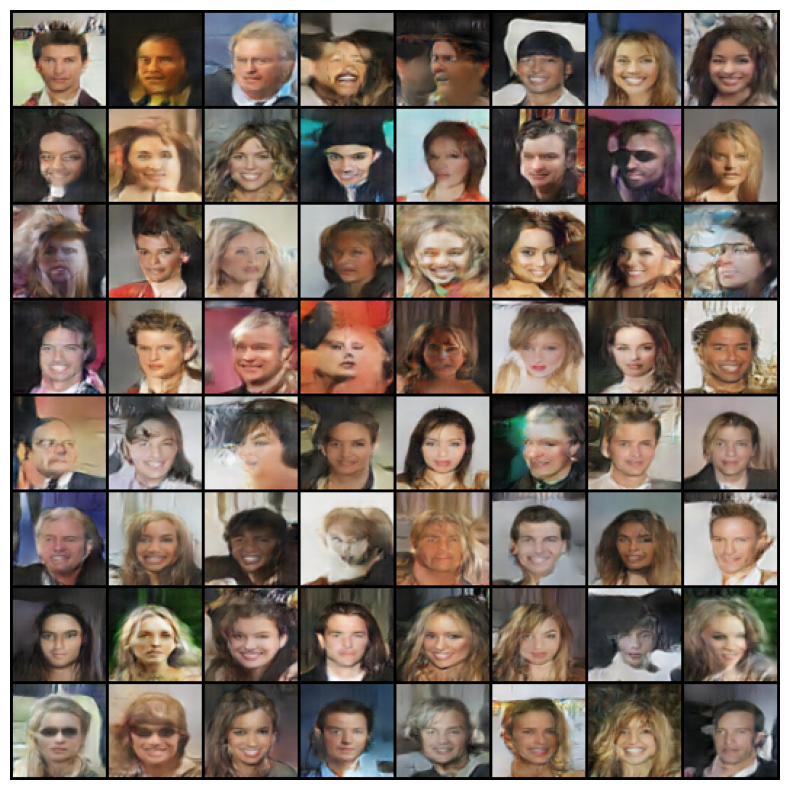

In [15]:
from huggingface_hub import hf_hub_download

# download weights from HF
netG_path = hf_hub_download(repo_id=REPO_ID, filename="netG_latest.pth", token=HF_TOKEN)

# recreate the model and load weights
netG = Generator(noise_dims=100).to(device)
netG.load_state_dict(torch.load(netG_path, map_location=device))
netG.eval()

# generate images
with torch.no_grad():
    fake = netG(fixed_noise)
    save_image(fake, "/kaggle/working/generated.png", normalize=True, nrow=8)

# show the image
from PIL import Image
img = Image.open("/kaggle/working/generated.png")
plt.figure(figsize=(10,10))
plt.imshow(img)
plt.axis("off")
plt.show()

In [ ]:
import os
import cv2
import matplotlib.pyplot as plt

# your base path
base_path = "/kaggle/input/datasets/jessicali9530/celeba-dataset"

# correct image folder
path = os.path.join(base_path, "img_align_celeba", "img_align_celeba")

# get some sample images
images = os.listdir(path)[:9]

plt.figure(figsize=(8,8))

for i, img_name in enumerate(images):
    img = cv2.imread(os.path.join(path, img_name))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    plt.subplot(3,3,i+1)
    plt.imshow(img)
    plt.axis('off')

plt.show()